In [1]:
import pandas as pd
import numpy as np

returns = pd.read_csv(
    "../data/processed/returns_computed.csv"
)

results = []

for fund in returns["amfi_code"].unique():

    r = returns[
        returns["amfi_code"] == fund
    ]["daily_return"].dropna()

    var_95 = np.percentile(r, 5)
    cvar_95 = r[r <= var_95].mean()

    results.append(
        [fund, var_95, cvar_95]
    )

var_cvar_report = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "var_95",
        "cvar_95"
    ]
)

var_cvar_report.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

var_cvar_report.head()

,amfi_code,var_95,cvar_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


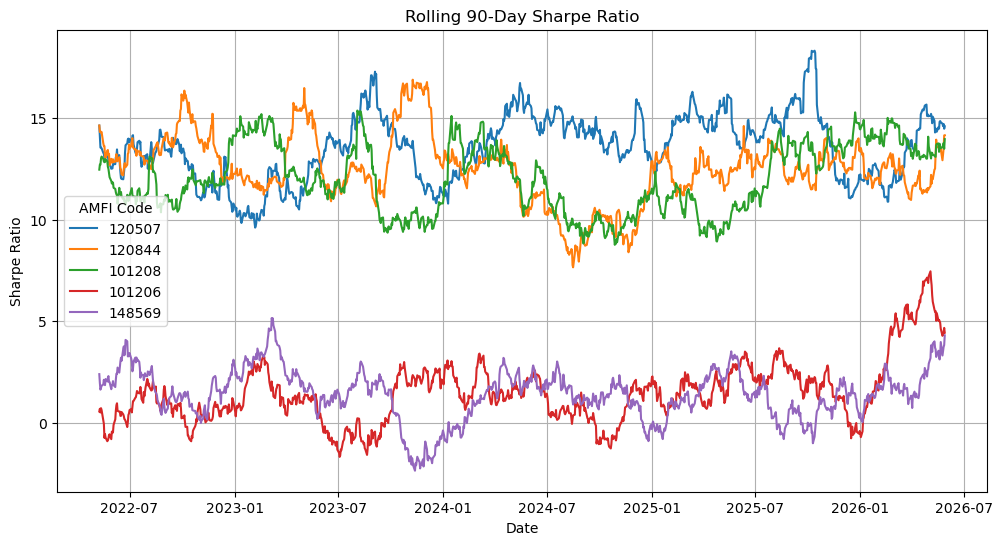

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

returns = pd.read_csv("../data/processed/returns_computed.csv")

returns["date"] = pd.to_datetime(returns["date"])

returns["rolling_sharpe"] = (
    returns.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        (x.rolling(90).mean() /
         x.rolling(90).std()) * np.sqrt(252)
    )
)

top_funds = (
    returns.groupby("amfi_code")["rolling_sharpe"]
    .last()
    .nlargest(5)
    .index
)

plt.figure(figsize=(12,6))

for fund in top_funds:
    data = returns[
        returns["amfi_code"] == fund
    ]

    plt.plot(
        data["date"],
        data["rolling_sharpe"],
        label=fund
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(title="AMFI Code")
plt.grid(True)
plt.show()

In [12]:
import pandas as pd

transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

first_txn = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

transactions = transactions.merge(
    first_txn[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

cohort_summary = (
    transactions.groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

fund_preference = (
    transactions.groupby(
        ["cohort_year", "amfi_code"]
    )["amount_inr"]
    .sum()
    .reset_index()
)

top_fund = (
    fund_preference.sort_values(
        ["cohort_year", "amount_inr"],
        ascending=False
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

cohort_analysis = cohort_summary.merge(
    top_fund[["cohort_year", "amfi_code"]],
    on="cohort_year"
)

cohort_analysis.rename(
    columns={
        "amfi_code": "fund_preference"
    },
    inplace=True
)

cohort_analysis.to_csv(
    "../data/processed/cohort_analysis.csv",
    index=False
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,fund_preference
0,2024,107422.541832,3491125187,102885
1,2025,109158.577061,30455243,119599


In [15]:
import pandas as pd

transactions = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

sip = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_analysis = (
    sip.groupby("investor_id")
    .agg(
        sip_count=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

sip_analysis = sip_analysis[
    sip_analysis["sip_count"] >= 6
]

sip_analysis["status"] = sip_analysis[
    "avg_gap_days"
].apply(
    lambda x: "At-Risk" if x > 35 else "Active"
)

sip_analysis.to_csv(
    "../data/processed/sip_continuity.csv",
    index=False
)

sip_analysis.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


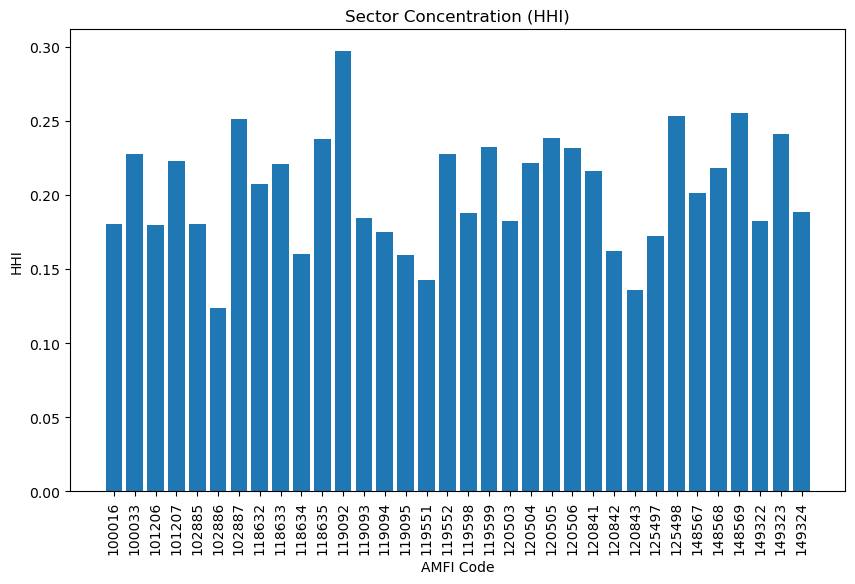

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

holdings = pd.read_csv(
    "../data/processed/clean_portfolio_holdings.csv"
)

sector_hhi = (
    holdings.groupby(
        ["amfi_code", "sector"]
    )["weight_pct"]
    .sum()
    .reset_index()
)

sector_hhi["weight_pct"] = (
    sector_hhi["weight_pct"] / 100
)

sector_hhi = (
    sector_hhi.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="hhi")
)

sector_hhi.to_csv(
    "../data/processed/sector_hhi.csv",
    index=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    sector_hhi["amfi_code"].astype(str),
    sector_hhi["hhi"]
)

plt.title("Sector Concentration (HHI)")
plt.xlabel("AMFI Code")
plt.ylabel("HHI")
plt.xticks(rotation=90)
plt.show()

Key Insights

- Funds with the lowest VaR and CVaR values showed the highest downside risk during adverse market conditions.

- Rolling 90-Day Sharpe Ratio analysis highlighted funds with improving as well as declining risk-adjusted performance over time.

- Investor cohort analysis revealed differences in investment behaviour between investors who started investing in different years.

- SIP continuity analysis identified multiple investors with average transaction gaps greater than 35 days, indicating potential SIP discontinuation risk.

- HHI analysis showed that some funds were highly concentrated in a few sectors, while others were better diversified.
